# 02 — Data Exploration

This notebook explores the **Solubility_AqSolDB** benchmark obtained from the Therapeutics Data Commons (TDC).

The objective of this stage is to understand the structure and main characteristics of the dataset before generating molecular representations or training machine learning models.

No data transformations are applied in this notebook. The original benchmark partitions provided by TDC are preserved.

## Objectives

- Inspect the structure and dimensions of the train/validation and test sets.
- Review column names and data types.
- Check for missing values and duplicated molecular structures.
- Examine the distribution and range of the target variable (`Y`).
- Identify potential data quality issues that may require further treatment.
- Establish the basis for the subsequent molecular feature engineering stage.


In [13]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from tdc import utils
from tdc.benchmark_group import admet_group

group = admet_group(path="../data/raw/")
benchmark = group.get("Solubility_AqSolDB")

Found local copy...


In [3]:
train_val = benchmark["train_val"].copy()
test = benchmark["test"].copy()

print("Train + validation")
print("------------------")
print("Shape:", train_val.shape)
print("Columns:", train_val.columns.tolist())

print()

print("Test")
print("----")
print("Shape:", test.shape)
print("Columns:", test.columns.tolist())

Train + validation
------------------
Shape: (7985, 3)
Columns: ['Drug_ID', 'Drug', 'Y']

Test
----
Shape: (1997, 3)
Columns: ['Drug_ID', 'Drug', 'Y']


In [ ]:
print("Train + validation dtypes:")
print(train_val.dtypes)

print("Test dtypes:")
print(test.dtypes)

Train + validation dtypes:
Drug_ID        str
Drug           str
Y          float64
dtype: object
Test dtypes:
Drug_ID        str
Drug           str
Y          float64
dtype: object


,Drug_ID,Drug,Y
0,4-chlorobenzaldehyde,O=Cc1ccc(Cl)cc1,-2.177078
1,vinyltoluene,C=Cc1cccc(C)c1,-3.123150
2,4-(dimethylamino)benzaldehyde,CN(C)c1ccc(C=O)cc1,-2.282769
3,2-methyl-1-phenylpropan-2-yl acetate,CC(=O)OC(C)(C)Cc1ccccc1,-2.394650
4,5-methoxy-1-[4-(trifluoromethyl)phenyl]pentan-...,COCCCCC(=O)c1ccc(C(F)(F)F)cc1,-3.544060


In [7]:
train_val.head()

,Drug_ID,Drug,Y
0,4-chlorobenzaldehyde,O=Cc1ccc(Cl)cc1,-2.177078
1,vinyltoluene,C=Cc1cccc(C)c1,-3.123150
2,4-(dimethylamino)benzaldehyde,CN(C)c1ccc(C=O)cc1,-2.282769
3,2-methyl-1-phenylpropan-2-yl acetate,CC(=O)OC(C)(C)Cc1ccccc1,-2.394650
4,5-methoxy-1-[4-(trifluoromethyl)phenyl]pentan-...,COCCCCC(=O)c1ccc(C(F)(F)F)cc1,-3.544060


In [ ]:
print("Train + validation nulls", train_val.isnull().sum())

print("Test nulls", test.isnull().sum())
    
# No missing values are present in the train + validation set.
# Additional checks are still required to assess molecular duplicates,
# target distribution, and structural validity.

Train + validation nulls Drug_ID    0
Drug       0
Y          0
dtype: int64
Test nulls Drug_ID    0
Drug       0
Y          0
dtype: int64


In [15]:
train_val["Y"].describe()

count    7985.000000
mean       -2.761690
std         2.368903
min       -12.060500
25%        -4.171800
50%        -2.467000
75%        -1.065100
max         1.967513
Name: Y, dtype: float64

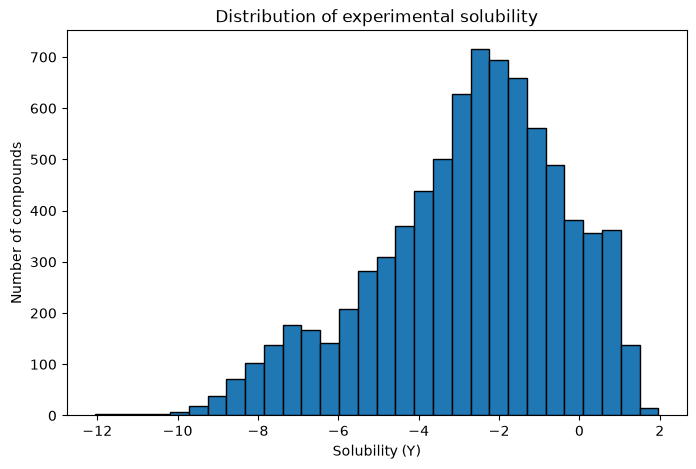

In [16]:

plt.figure(figsize=(8, 5))

plt.hist(
    train_val["Y"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Solubility (Y)")
plt.ylabel("Number of compounds")
plt.title("Distribution of experimental solubility")

plt.show()

In [12]:
train_val["Drug"].duplicated().sum()

0